In [1]:
from torchvision import datasets, transforms

train_data = datasets.FashionMNIST(
    root="D:/ml-dl-bootcamp/data/fashion_mnist",
    train=True, download=True, transform=transforms.ToTensor())
print("训练样本数:", len(train_data))
img, label = train_data[0]
print("图片张量形状:", img.shape)
print("标签编号:", label, "→", train_data.classes[label])


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 180kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

训练样本数: 60000
图片张量形状: torch.Size([1, 28, 28])
标签编号: 9 → Ankle boot


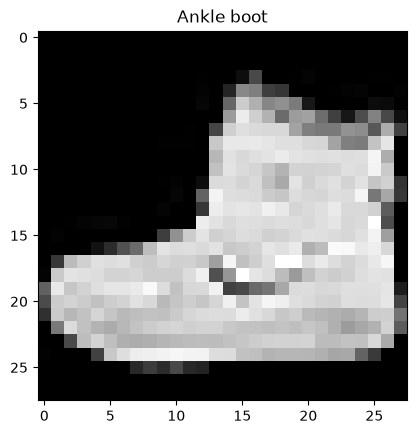

In [2]:
import matplotlib.pyplot as plt

plt.imshow(img.squeeze(), cmap="gray")
plt.title(train_data.classes[label])
plt.show()

In [4]:
import torch

img, label = train_data[0]
print("整张图片的形状:", img.shape)        # torch.Size([1, 28, 28])
print("通道数:", img.shape[0])             # 1 = 灰度图（彩色会是 3）
print("高:", img.shape[1], " 宽:", img.shape[2])

print("第一行前 10 个像素值:", img[0, 0, :10])
print("最小像素值:", img.min().item(), "| 最大像素值:", img.max().item())

flat = img.reshape(-1)                     # 把 28×28 拉直成一维
print("拉直后的数字个数:", flat.shape)      # 应该是 784


整张图片的形状: torch.Size([1, 28, 28])
通道数: 1
高: 28  宽: 28
第一行前 10 个像素值: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
最小像素值: 0.0 | 最大像素值: 1.0
拉直后的数字个数: torch.Size([784])


In [5]:
import torch
import torch.nn as nn

class ClothesMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),            # 28×28 拉直 → 784
            nn.Linear(784, 256),     # 第 1 层：784 → 256
            nn.ReLU(),               # 激活函数
            nn.Linear(256, 10),      # 第 2 层：256 → 10
        )

    def forward(self, x):
        return self.net(x)

model = ClothesMLP()
print(model)


ClothesMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
total = sum(p.numel() for p in model.parameters())
print("模型参数量:", total)

模型参数量: 203530


In [7]:
fake_batch = torch.randn(4, 1, 28, 28)   # 4 张 28×28 的"假图"
out = model(fake_batch)
print("输出形状:", out.shape)             # 应该是 [4, 10]

输出形状: torch.Size([4, 10])


In [10]:
import torch.nn as nn
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

loss_fn = nn.CrossEntropyLoss()                          # 损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # 优化器

for epoch in range(3):                                   # 全部图片学 3 遍
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        out = model(xb)                # ① 前向：64 张图 → 64×10 的分数
        loss = loss_fn(out, yb)        # ② 算损失：预测和正确答案差多少
        optimizer.zero_grad()          # ③ 清空上次梯度
        loss.backward()                # ④ 反向传播：算出 20 万个参数各自的梯度
        optimizer.step()               # ⑤ 按梯度更新参数（学一次）
        total_loss += loss.item() * len(xb)
        correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)
    print(f"epoch {epoch+1}: loss={total_loss/total:.4f} acc={correct/total:.4f}")
    

epoch 1: loss=0.2667 acc=0.9014
epoch 2: loss=0.2553 acc=0.9060
epoch 3: loss=0.2453 acc=0.9083


In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_data = datasets.FashionMNIST(
    root="D:/ml-dl-bootcamp/data/fashion_mnist",
    train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [12]:
model.eval()           # 切换到评估模式
correct, total = 0, 0
with torch.no_grad():  # 评估不用算梯度，省内存、跑得快
    for xb, yb in test_loader:
        out = model(xb)
        correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)
print(f"测试集精度: {correct/total:.4f}")

测试集精度: 0.8858


C:\Users\28917\AppData\Local\Temp\ipykernel_33564\786671641.py:20: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28917\AppData\Local\Temp\ipykernel_33564\786671641.py:20: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28917\AppData\Local\Temp\ipykernel_33564\786671641.py:20: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\conda\envs\ml-dl\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\conda\envs\ml-dl\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\conda\envs\ml-dl\Lib\site-packages\IPython\core\p

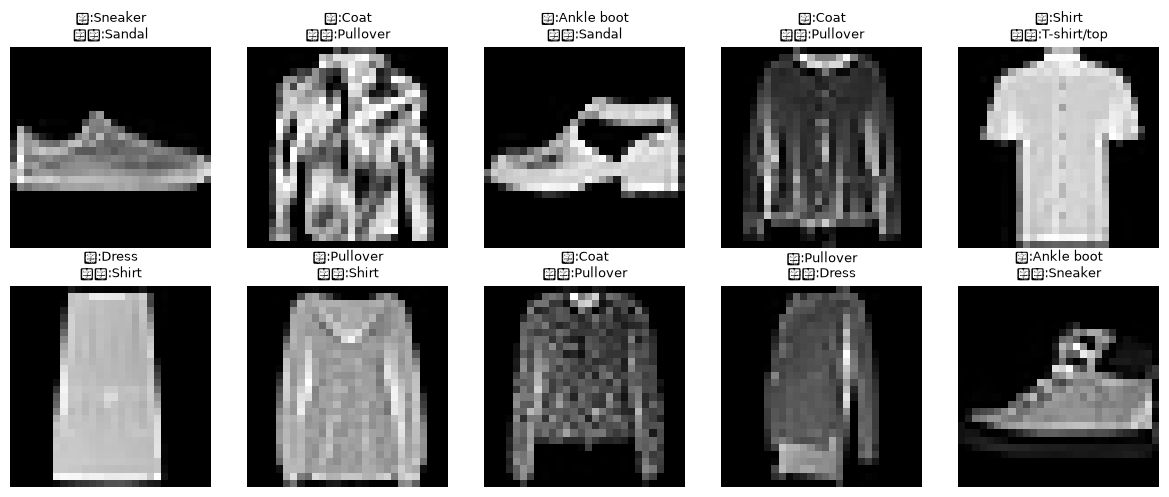

In [13]:
import matplotlib.pyplot as plt

wrong = []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb)
        pred = out.argmax(1)
        for i in range(len(yb)):
            if pred[i] != yb[i]:
                wrong.append((xb[i], yb[i], pred[i]))
        if len(wrong) >= 10:
            break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, (img, true, pred) in enumerate(wrong[:10]):
    ax = axes[i // 5][i % 5]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"真:{test_data.classes[true]}\n预测:{test_data.classes[pred]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()